In [21]:
# COLOCAR SIMULADOR DE VOO COMPLETO AQUI
# RODAR OS ESTADOS SEPARADOS E PLOTAR RESULTADOS DE DADA UM DELES SEPARADAMENTE, PARA VER SE O REWARD ESTÁ FUNCIONANDO COMO DEVE
# Rodar por X steps e calcular a eficiência da etapa em comparação com a inicial, além das características do perfil (tickness, camber, etc) para ver se o agente está aprendendo a otimizar as características aerodinâmicas de forma consistente com o que esperamos
# Scatter plot com camber no x e tickness no y, colorido pela eficiência, para ver se o agente está aprendendo a otimizar as características aerodinâmicas de forma consistente com o que esperamos

In [22]:
import os 
import sys
from pathlib import Path

# Find the project root (the nearest ancestor that contains `src`) and add it to sys.path FIRST
cwd = Path.cwd()
project_root = cwd
for _ in range(6):
    if (project_root / "src").exists():
        break
    if project_root.parent == project_root:
        break
    project_root = project_root.parent
else:
    project_root = cwd

proj_path = str(project_root.resolve())
if proj_path not in sys.path:
    # Insert at front so local packages take precedence
    sys.path.insert(0, proj_path)


In [23]:
RUN_ID = "20260307-145624"

PROJECT_PATH = Path(proj_path)
MODELS_PATH = PROJECT_PATH / "models"
ONNX_MODELS_PATH = MODELS_PATH / "onnx_decoder"

# 1. Convert iterdir() to a list to check its length safely
onnx_files = list(ONNX_MODELS_PATH.iterdir())

if len(onnx_files) != 2:
    raise ValueError(
        f"Expected exactly 2 files in {ONNX_MODELS_PATH} (Decoder and Scaler), but found {len(onnx_files)}."
    )

# Since pathlib handles the absolute/relative paths internally, this is perfectly safe.
SCALER_PATH = list(ONNX_MODELS_PATH.glob("*.pkl"))[0]
DECODER_PATH = list(ONNX_MODELS_PATH.glob("*.onnx"))[0]

# Optional: Print them out to verify they look correct
print(f"Loaded Scaler from: {SCALER_PATH}")
print(f"Loaded Decoder from: {DECODER_PATH}")

MODEL_PATH = MODELS_PATH / RUN_ID / "best_model" / "best_model.zip" 

if not MODEL_PATH.exists():
    raise FileNotFoundError(f"Model file not found at {MODEL_PATH}. Please check the path and try again.")
else:
    print(f"Loaded RL model from: {MODEL_PATH}")

Loaded Scaler from: C:\Users\matso\OneDrive\Desktop\Code\Py\AeroRL-Optimizer\models\onnx_decoder\20260221-165429_scaler.pkl
Loaded Decoder from: C:\Users\matso\OneDrive\Desktop\Code\Py\AeroRL-Optimizer\models\onnx_decoder\20260221-165429_decoder.onnx
Loaded RL model from: C:\Users\matso\OneDrive\Desktop\Code\Py\AeroRL-Optimizer\models\20260307-145624\best_model\best_model.zip



🚀 Iniciando Validação de Robustez: FASE 1 (DASH)

Ep 01 | Eficiência: 918.36 -> 1715.87 | Erro CL:  0.02 | Alpha:   7.3° ->   2.2°
Ep 02 | Eficiência: 1083.14 -> 1996.29 | Erro CL:  0.02 | Alpha:   0.1° ->   1.7°
Ep 03 | Eficiência: 986.22 -> 1840.97 | Erro CL:  0.02 | Alpha:  -0.4° ->   2.7°
Ep 04 | Eficiência: 1382.98 -> 2000.00 | Erro CL:  0.03 | Alpha:  -1.4° ->   1.2°
Ep 05 | Eficiência: 1287.92 -> 1691.44 | Erro CL:  0.02 | Alpha:   4.7° ->   2.7°
Ep 06 | Eficiência: 1613.59 -> 2000.00 | Erro CL:  0.00 | Alpha:  -1.9° ->   0.1°
Ep 07 | Eficiência: 1490.08 -> 1878.87 | Erro CL:  0.02 | Alpha:  -0.4° ->   1.2°
Ep 08 | Eficiência: 1049.49 -> 1839.24 | Erro CL:  0.02 | Alpha:   2.2° ->   1.2°
Ep 09 | Eficiência: 1792.56 -> 2000.00 | Erro CL:  0.02 | Alpha:   0.6° ->   1.2°
Ep 10 | Eficiência: 1967.92 -> 1967.92 | Erro CL:  0.01 | Alpha:   1.2° ->   1.2°
Ep 11 | Eficiência: 1271.84 -> 2000.00 | Erro CL:  0.01 | Alpha:  -4.5° ->   1.2°
Ep 12 | Eficiência: 1072.62 -> 2000.00 | Erro CL:

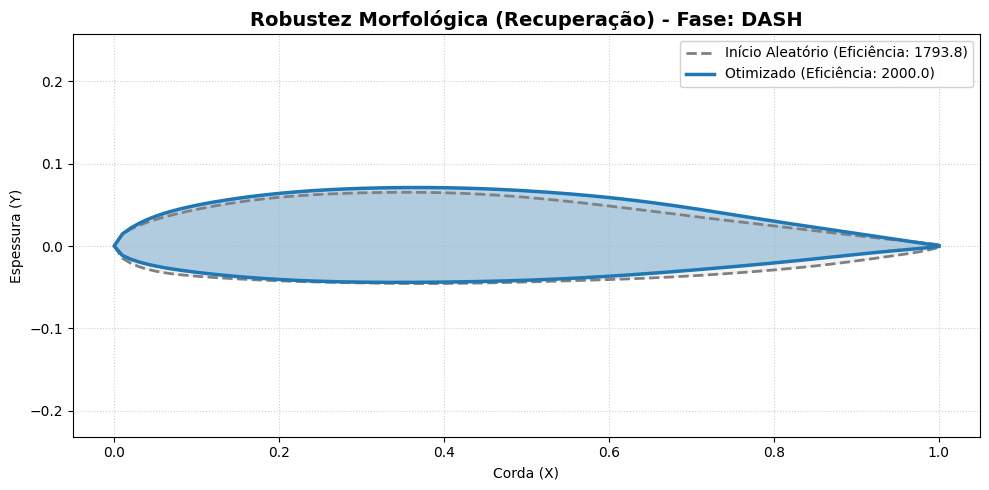

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from stable_baselines3 import PPO
from src.enviroments import MultiStageOptEnv

# ==========================================
# CONFIGURAÇÕES DA VALIDAÇÃO
# ==========================================

EPISODES = 50           # Quantos voos de teste vamos rodar
STEPS = 50
TARGET_STAGE = 2        # 0=Ascent, 1=Dash, 2=Loiter, 3=Cruise

# Dicionário para impressão bonita
STAGE_NAMES = {0: "ASCENT", 1: "DASH", 2: "LOITER", 3: "CRUISE"}

def run_validation():
    print(f"\n🚀 Iniciando Validação de Robustez: FASE {TARGET_STAGE} ({STAGE_NAMES[TARGET_STAGE]})\n")
    
    env = MultiStageOptEnv(
        scaler_path=SCALER_PATH,
        decoder_path=DECODER_PATH,
        max_episode_steps=50
    )
    
    model = PPO.load(MODEL_PATH)
    
    initial_efficiencies = []
    final_efficiencies = []
    
    # Vetor de alphas do ambiente (para achar o ângulo de ataque)
    alphas = np.linspace(env.unwrapped.lower_alpha, env.unwrapped.upper_alpha, env.unwrapped.n_alphas)

    # Variáveis seguras para plotagem
    plot_coords_initial = env.unwrapped._get_coords().copy()
    plot_coords_final = env.unwrapped._get_coords().copy()

    for ep in range(EPISODES):
        # 1. Reset sorteia uma asa completamente aleatória e caótica (Robustez)
        obs, info = env.reset()
        
        # 2. Travamos apenas as condições de voo da fase que queremos testar
        env.unwrapped._current_stage = TARGET_STAGE
        env.unwrapped._re, env.unwrapped._mach, env.unwrapped._current_target_cl = env.unwrapped._get_flight_conditions()
        obs = env.unwrapped._get_obs()
        
        # 3. Pegamos a performance INICIAL (Caótica)
        zero_action = np.zeros(env.action_space.shape, dtype=np.float32)
        obs, _, _, _, info = env.step(zero_action)
        
        initial_eff = env.unwrapped._current_stage_efficiency
        initial_efficiencies.append(initial_eff)
        
        # Onde estava o erro de CL e o Alpha na asa caótica?
        idx_init = np.argmin(np.abs(info['cl_sweep'] - info['target_cl']))
        err_init = abs(info['cl_sweep'][idx_init] - info['target_cl'])
        alpha_init = alphas[idx_init]
        
        # Salva o formato inicial para o gráfico (se for a última rodada)
        plot_coords_initial = env.unwrapped._get_coords().copy()

        # --- LÓGICA DE PEAK HOLD ---
        best_eff_found = initial_eff
        best_err_found = err_init
        best_alpha_found = alpha_init
        best_coords = plot_coords_initial.copy()

        # 4. O Piloto Automático assume (Damos 80 passos para consertar geometrias terríveis)
        for _ in range(STEPS):
            action, _states = model.predict(obs, deterministic=True)
            obs, reward, terminated, truncated, info = env.step(action)
            
            current_eff = env.unwrapped._current_stage_efficiency
            idx_curr = np.argmin(np.abs(info['cl_sweep'] - info['target_cl']))
            current_err = abs(info['cl_sweep'][idx_curr] - info['target_cl'])
            current_alpha = alphas[idx_curr]
            
            # Se a IA achou uma asa mais eficiente e segura (Erro CL <= 0.05), nós travamos e salvamos!
            if current_eff > best_eff_found and current_err <= 0.05:
                best_eff_found = current_eff
                best_err_found = current_err
                best_alpha_found = current_alpha
                best_coords = env.unwrapped._get_coords().copy()

            if terminated or truncated:
                break

        # 5. Guardamos a MELHOR performance do episódio
        final_efficiencies.append(best_eff_found)
        plot_coords_final = best_coords.copy()
            
        print(f"Ep {ep+1:02d} | Eficiência: {initial_eff:6.2f} -> {best_eff_found:6.2f} | "
              f"Erro CL: {best_err_found:5.2f} | Alpha: {alpha_init:5.1f}° -> {best_alpha_found:5.1f}°")

    # ==========================================
    # RESULTADOS ESTATÍSTICOS
    # ==========================================
    mean_initial = np.mean(initial_efficiencies)
    mean_final = np.mean(final_efficiencies)
    improvement = ((mean_final - mean_initial) / abs(mean_initial)) * 100

    print("\n" + "="*50)
    print(f"📊 RESUMO DA VALIDAÇÃO - FASE {TARGET_STAGE} ({STAGE_NAMES[TARGET_STAGE]})")
    print("="*50)
    print(f"Média Inicial Aleatória   : {mean_initial:.2f}")
    print(f"Média Final Otimizada     : {mean_final:.2f}")
    print(f"Recuperação de Eficiência : +{improvement:.2f}%")
    print("="*50 + "\n")

    # ==========================================
    # PLOT DE SOBREPOSIÇÃO (OVERLAP)
    # ==========================================
    print("Gerando gráfico de sobreposição do último episódio...")
    plt.figure(figsize=(10, 5))
    
    x_init, y_init = plot_coords_initial[:, 0], plot_coords_initial[:, 1]
    x_final, y_final = plot_coords_final[:, 0], plot_coords_final[:, 1]
    
    plt.plot(x_init, y_init, color='gray', linestyle='--', linewidth=2, label=f'Início Aleatório (Eficiência: {initial_efficiencies[-1]:.1f})')
    plt.fill(x_init, y_init, color='gray', alpha=0.1)
    
    plt.plot(x_final, y_final, color='tab:blue', linewidth=2.5, label=f'Otimizado (Eficiência: {final_efficiencies[-1]:.1f})')
    plt.fill(x_final, y_final, color='tab:blue', alpha=0.3)
    
    plt.title(f"Robustez Morfológica (Recuperação) - Fase: {STAGE_NAMES[TARGET_STAGE]}", fontsize=14, fontweight='bold')
    plt.xlabel("Corda (X)")
    plt.ylabel("Espessura (Y)")
    plt.grid(True, linestyle=":", alpha=0.6)
    plt.axis("equal")
    plt.legend(loc="upper right", framealpha=0.9)
    
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    run_validation()